# Taller Pandas

### **Instrucciones:**

1. Formula al menos 3 preguntas de análisis sobre tu conjunto de datos
2. Utilizando Pandas:
  - Limpieza de datos (Pandas: dropna, fillna, replace, etc.)
  - Filtrado y selección de datos
  - Transformación de columnas, creación de variables nuevas
  - Agrupaciones y resúmenes (groupby)
3. Responde las preguntas planteadas con una breve interpretación.

### **Ejemplos de preguntas para el reto:**
- ¿Cuál es el promedio de ventas por mes?
- ¿Cómo cambian la cantidad de productos exportados a lo largo del tiempo?
- ¿Hay valores atípicos en alguna columna numérica? ¿Cómo los tratarías?
- ¿Cuál es la categoría más frecuente y qué la distingue en el dataset?
- ¿Qué porcentaje de transacciones tiene una cantidad vendida superior al promedio?
- ¿Qué días tuvieron ventas totales fuera de lo común (muy altas o muy bajas)?

In [1]:
import pandas as pd
print("¡Pandas importado correctamente!")



¡Pandas importado correctamente!


In [2]:
import numpy as np
print("numpy importado correctamente!")

numpy importado correctamente!


In [3]:
!pip install openpyxl
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
ventas_data = pd.read_excel('Datos.xlsx')
ventas_data1 = ventas_data
ventas_data1.head()

,No. Factura,FECHA,PAIS DESTINO,CATEGORIA VENTA,ARTICULO VENTA,CANTIDAD VENDIDA,PRECIO UNITARIO
0,101-17-6199,2021-06-14,México,Aseo,Escoba,140,1600
1,101-81-4070,2021-04-08,Brasil,Oficina,Borrador,10,1900
2,102-06-2002,2022-04-29,Perú,Oficina,Boligrafo,110,19990
3,102-77-2261,2022-04-09,México,Oficina,Boligrafo,160,8990
4,105-10-6182,2021-02-08,Perú,Aseo,Escoba,180,1600


## Preguntas de Análisis

### 1. ¿Cuales es el pais con mas ventas?

In [5]:
#1. Se crea una nueva columna llamada Valor neto
ventas_data1['VALOR NETO'] = ventas_data1['CANTIDAD VENDIDA'] * ventas_data1['PRECIO UNITARIO']
ventas_data1.head()

,No. Factura,FECHA,PAIS DESTINO,CATEGORIA VENTA,ARTICULO VENTA,CANTIDAD VENDIDA,PRECIO UNITARIO,VALOR NETO
0,101-17-6199,2021-06-14,México,Aseo,Escoba,140,1600,224000
1,101-81-4070,2021-04-08,Brasil,Oficina,Borrador,10,1900,19000
2,102-06-2002,2022-04-29,Perú,Oficina,Boligrafo,110,19990,2198900
3,102-77-2261,2022-04-09,México,Oficina,Boligrafo,160,8990,1438400
4,105-10-6182,2021-02-08,Perú,Aseo,Escoba,180,1600,288000


In [7]:
#2. Se agrupan las ventas de cada pais
ventas_pais = ventas_data1.groupby('PAIS DESTINO')['VALOR NETO'].sum()
ventas_pais

PAIS DESTINO
Brasil       104526040
Chile         97677690
Colombia    1372775600
España      1053785700
México       101423000
Perú        1388800500
Name: VALOR NETO, dtype: int64

In [10]:
#3. Se busca cual es el maximo entre todos los paises
pais_mayor_venta = ventas_pais.idxmax()
total_ventas = ventas_pais.max()

print(f"El país con mayor venta es {pais_mayor_venta} con un total de {total_ventas}")

El país con mayor venta es Perú con un total de 1388800500


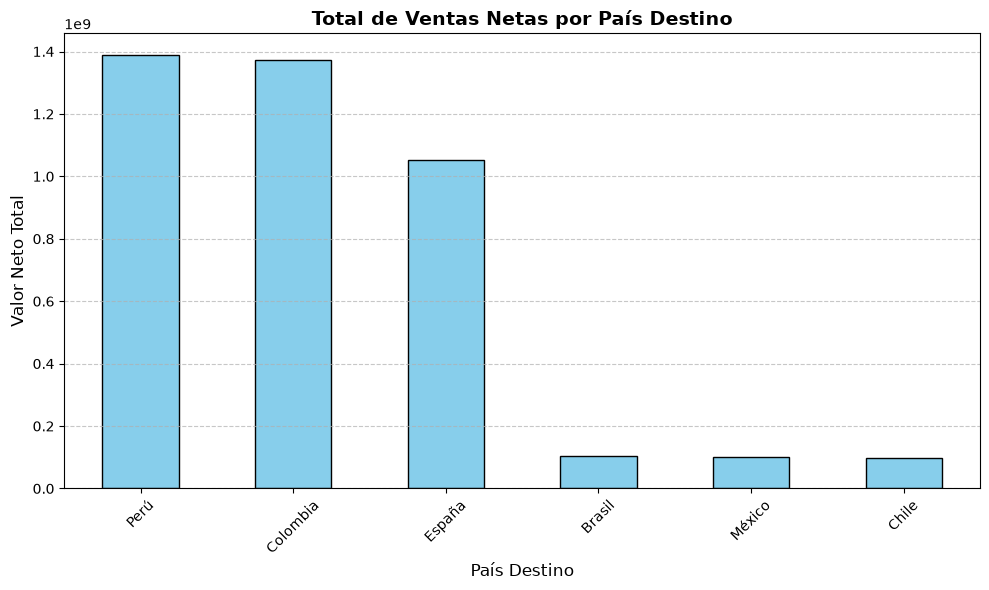

In [11]:
import matplotlib.pyplot as plt

# 1. Agrupar, sumar y ordenar los datos de mayor a menor
ventas_por_pais = ventas_data.groupby('PAIS DESTINO')['VALOR NETO'].sum().sort_values(ascending=False)

# 2. Crear el gráfico de barras
plt.figure(figsize=(10, 6))
ventas_por_pais.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Personalizar el diseño del gráfico
plt.title('Total de Ventas Netas por País Destino', fontsize=14, fontweight='bold')
plt.xlabel('País Destino', fontsize=12)
plt.ylabel('Valor Neto Total', fontsize=12)
plt.xticks(rotation=45) # Rota los nombres de los países para que se lean mejor
plt.grid(axis='y', linestyle='--', alpha=0.7) # Agrega líneas guía horizontales

# 4. Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()



In [6]:
duplicados = ventas_data.duplicated().sum()
print(f"Se encontraron {duplicados} filas duplicadas.")

Se encontraron 0 filas duplicadas.


### Cual es el producto mas vendido en Perú ?

In [19]:
## Se filtra solo Peru

ventas_peru = ventas_data1[ventas_data1['PAIS DESTINO'] == 'Perú']

# Se agrupan las ventas por articulo
ventas_peru_max = ventas_peru.groupby('ARTICULO VENTA')['VALOR NETO'].sum()
 
# Se selecciona el valor maximo de venta y cual es el producto 
masvendido_peru= ventas_peru_max.idxmax()
total_productobr= ventas_peru_max.max()

print(f"El producto más vendido en Peru es '{masvendido_peru}' con un total de {total_productobr}")


El producto más vendido en Peru es 'Boligrafo' con un total de 1307855000


### Cual es el producto mas vendido en cada uno de los Paises?

In [29]:
# 1. Agrupar por país y artículo, y sumar las ventas netas
ventas_combinadas = ventas_data1.groupby(['PAIS DESTINO', 'ARTICULO VENTA'])['VALOR NETO'].sum().reset_index()

# 2. Ordenar de mayor a menor para asegurar que el máximo quede arriba
ventas_combinadas = ventas_combinadas.sort_values('VALOR NETO', ascending=False)

# 3. Quedarse solo con el primer registro (el más alto) de cada país
productos_top_por_pais = ventas_combinadas.drop_duplicates(subset=['PAIS DESTINO'], keep='first')

# 4. Mostrar el resultado ordenado y limpio
print(productos_top_por_pais.to_string(index=False))

PAIS DESTINO ARTICULO VENTA  VALOR NETO
    Colombia      Boligrafo  1316573100
        Perú      Boligrafo  1307855000
      España      Boligrafo   993348500
      México      Boligrafo    55119800
      Brasil      Boligrafo    54307700
       Chile      Boligrafo    51794300


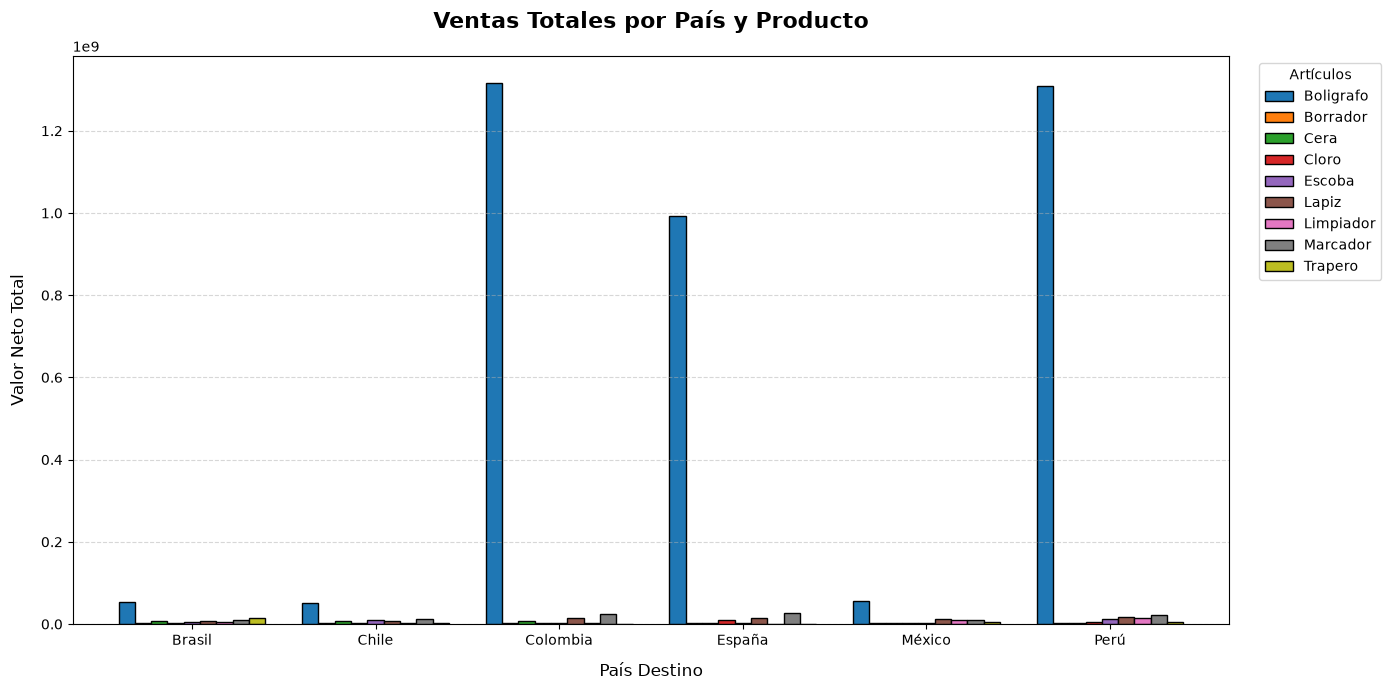

In [30]:
import matplotlib.pyplot as plt

# 1. Agrupar por país y producto, y sumar el valor neto
grupo_ventas = ventas_data1.groupby(['PAIS DESTINO', 'ARTICULO VENTA'])['VALOR NETO'].sum()

# 2. Transformar los datos para el gráfico (pasa los productos a columnas)
tabla_grafico = grupo_ventas.unstack(fill_value=0)

# 3. Crear el gráfico de barras agrupadas
ax = tabla_grafico.plot(kind='bar', figsize=(14, 7), width=0.8, edgecolor='black')

# 4. Personalizar el diseño
plt.title('Ventas Totales por País y Producto', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('País Destino', fontsize=12, labelpad=10)
plt.ylabel('Valor Neto Total', fontsize=12, labelpad=10)
plt.xticks(rotation=0)  # Mantiene los nombres de los países horizontales
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Configurar la leyenda (cuadro de productos) para que no tape las barras
plt.legend(title='Artículos', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

# 6. Ajustar y mostrar
plt.tight_layout()
plt.show()

### Cual es el producto menos vendido en cada uno de los paises?

In [20]:
# 1. Agrupar por país y artículo, y sumar las ventas netas
ventas_combinadas2 = ventas_data1.groupby(['PAIS DESTINO', 'ARTICULO VENTA'])['VALOR NETO'].sum().reset_index()

# 2. Ordenar de mayor a menor para asegurar que el máximo quede arriba
ventas_combinadas2 = ventas_combinadas2.sort_values('VALOR NETO', ascending=True)

# 3. Quedarse solo con el primer registro (el más alto) de cada país
productos_menos_vendidos = ventas_combinadas2.drop_duplicates(subset=['PAIS DESTINO'], keep='first')

# 4. Mostrar el resultado ordenado y limpio
print(productos_menos_vendidos.to_string(index=False))

PAIS DESTINO ARTICULO VENTA  VALOR NETO
      España        Trapero      994000
    Colombia        Trapero     1008000
      Brasil          Cloro     1660800
       Chile       Borrador     1729000
      México          Cloro     1897800
        Perú           Cera     1921000
